In [1]:
import os
import pypsa
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import folium
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# ============================================================================
# PUBLISHABLE AESTHETICS SETUP
# ============================================================================
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.autolayout': True,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# ============================================================================
# CONFIGURATION 
# ============================================================================
RUN_NAME = "2020_baseline"
SIMPL    = ""
CLUSTERS = "10"
RDIR     = f"{RUN_NAME}/" if RUN_NAME else ""

# File Paths
BUSMAP_PATH  = f"../resources/{RDIR}bus_regions/busmap_elec_s{SIMPL}_{CLUSTERS}.csv"
PRE_NET      = f"../networks/{RDIR}elec_s{SIMPL}.nc"
SOLVED_NET   = f"../results/{RDIR}networks/elec_s_10_ec_lcopt_3h.nc"
DEMAND_CSV   = f"../resources/{RDIR}demand_profiles.csv"
REGIONS_PATH = f"../resources/{RDIR}bus_regions/regions_onshore_elec_s{SIMPL}_{CLUSTERS}.geojson"
OUT_DIR      = "analysis/outputs/combined_analysis"

os.makedirs(OUT_DIR, exist_ok=True)

# Unified Color Palette
CARRIER_COLORS = {
    "solar": "#f9d71c", "onwind": "#235ebc", "offwind-ac": "#6895dd", "offwind-dc": "#74c6f2",
    "hydro": "#3dbfb0", "ror": "#298c81", "geothermal": "#ba2626", "biomass": "#8B4513",
    "CCGT": "#b35c00", "OCGT": "#e66c00", "coal": "#333333", "nuclear": "#E377C2",
    "oil": "#808080", "battery": "#9467BD", "load shedding": "#FF0000"
}

RENEWABLE_CARRIERS = ["solar", "onwind", "offwind-ac", "offwind-dc", "ror", "geothermal", "hydro", "biomass"]

print(f"Output directory ready: {OUT_DIR}/")

Output directory ready: analysis/outputs/combined_analysis/


In [2]:
print("=" * 80)
print("LOADING DATA & NETWORKS")
print("=" * 80)

# 1. Load Busmap
print(f"Loading busmap  : {BUSMAP_PATH}")
busmap = pd.read_csv(BUSMAP_PATH, index_col=0).squeeze("columns")
busmap.index = busmap.index.astype(str)
busmap.name = "cluster"

# 2. Load Geographic Regions
print(f"Loading regions : {REGIONS_PATH}")
try:
    regions_gdf = gpd.read_file(REGIONS_PATH)
    country_outline = regions_gdf.dissolve()
except Exception as e:
    print(f"⚠ WARNING: Could not load geographic regions ({e}). Maps will lack country borders.")
    regions_gdf = None
    country_outline = None

# 3. Load Pre-Clustering Network
print(f"Loading pre-net : {PRE_NET}")
n_pre = pypsa.Network(PRE_NET)

# 4. Load Solved Network
print(f"Loading solved  : {SOLVED_NET}")
n_solved = pypsa.Network(SOLVED_NET)

# Sanity Check for Solved Network
obj = getattr(n_solved, "objective", None)
if obj is None or (isinstance(obj, float) and np.isnan(obj)):
    print("\n⚠ WARNING: n_solved.objective is NaN — this may be the pre-solve network.")
else:
    print(f"  ✓ Network is solved. Objective value: {obj:,.0f}")

LOADING DATA & NETWORKS
Loading busmap  : ../resources/2020_baseline/bus_regions/busmap_elec_s_10.csv
Loading regions : ../resources/2020_baseline/bus_regions/regions_onshore_elec_s_10.geojson
Loading pre-net : ../networks/2020_baseline/elec_s.nc


INFO:pypsa.io:Imported network elec_s.nc has buses, carriers, generators, lines, links, loads, storage_units


Loading solved  : ../results/2020_baseline/networks/elec_s_10_ec_lcopt_3h.nc


INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_3h.nc has buses, carriers, generators, lines, links, loads, storage_units


  ✓ Network is solved. Objective value: 33,464,832


1. BUSMAP OVERVIEW & PRE-CLUSTERING ANALYSIS
Original buses (pre-clustering): 30 | Resulting clusters: 10


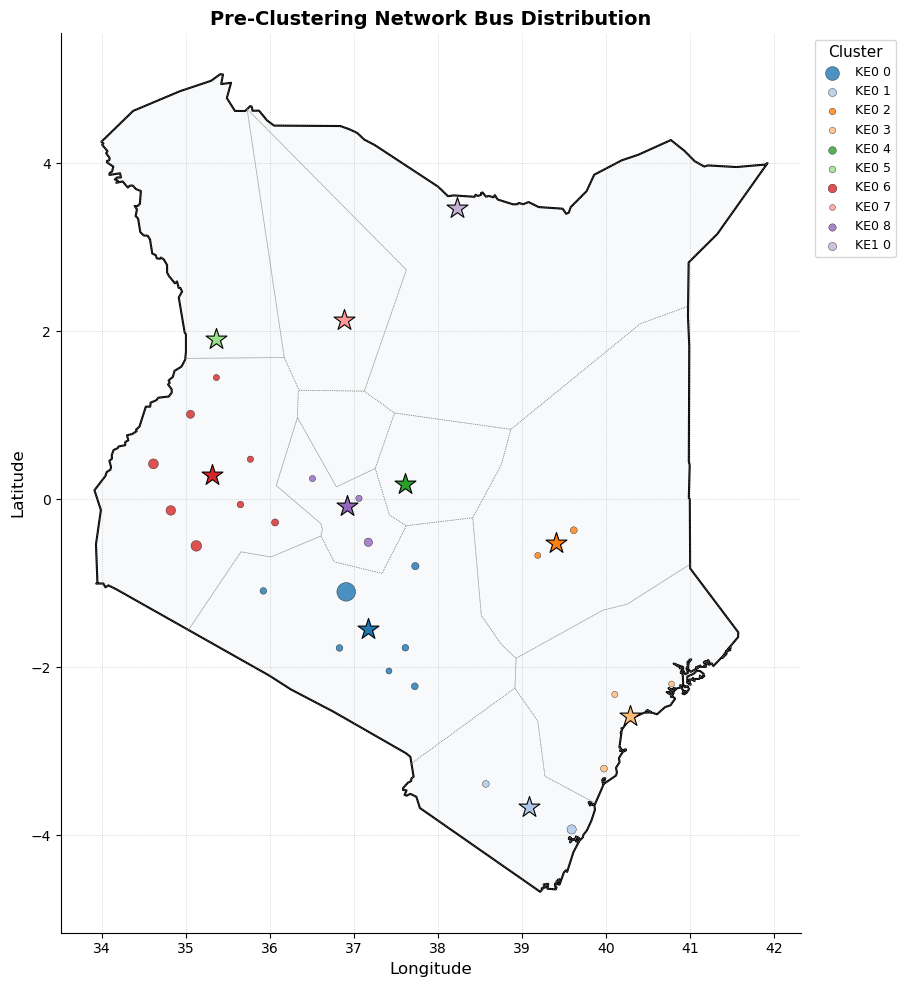

In [3]:
print("=" * 80)
print("1. BUSMAP OVERVIEW & PRE-CLUSTERING ANALYSIS")
print("=" * 80)

n_orig = len(busmap)
n_clusters = busmap.nunique()
print(f"Original buses (pre-clustering): {n_orig} | Resulting clusters: {n_clusters}")

buses_pre = n_pre.buses[["x", "y", "country", "carrier"]].copy()
buses_pre.index = buses_pre.index.astype(str)
buses_pre["cluster"] = busmap.reindex(buses_pre.index)

if not n_pre.loads_t.p_set.empty:
    avg_load = n_pre.loads_t.p_set.mean().rename_axis("load").to_frame("avg_load_MW")
    load_by_bus = n_pre.loads[["bus"]].join(avg_load).groupby("bus")["avg_load_MW"].sum()
else:
    load_by_bus = pd.Series(0.0, index=buses_pre.index)

buses_pre["avg_load_MW"] = load_by_bus.reindex(buses_pre.index, fill_value=0.0)

# ── Publishable Plot: Original Buses on Map ──
fig, ax = plt.subplots(figsize=(10, 10))

if country_outline is not None:
    country_outline.plot(ax=ax, facecolor='#f8f9fa', edgecolor='black', linewidth=1.5, zorder=1)
    regions_gdf.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.5, linestyle=':', zorder=2)

COLORS = plt.cm.tab20.colors
cluster_ids = sorted(busmap.unique())
color_map = {c: COLORS[i % len(COLORS)] for i, c in enumerate(cluster_ids)}

for cluster in cluster_ids:
    mask = buses_pre["cluster"] == cluster
    ax.scatter(buses_pre.loc[mask, "x"], buses_pre.loc[mask, "y"],
               s=buses_pre.loc[mask, "avg_load_MW"].clip(lower=5) * 0.4 + 15,
               color=color_map[cluster], alpha=0.8, edgecolor='black', linewidth=0.3, label=str(cluster), zorder=3)
    ax.scatter(buses_pre.loc[mask, "x"].mean(), buses_pre.loc[mask, "y"].mean(), 
               marker="*", s=250, color=color_map[cluster], edgecolors="black", linewidths=0.8, zorder=5)

ax.set_title("Pre-Clustering Network Bus Distribution", fontweight='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_aspect('equal')
ax.grid(color='grey', linestyle=':', linewidth=0.5, alpha=0.5)

fig.savefig(f"{OUT_DIR}/01_buses_by_cluster.png")
fig.savefig(f"{OUT_DIR}/01_buses_by_cluster.pdf")
plt.show()

In [4]:
print("=" * 80)
print("2. FINAL INSTALLED POWER MIX & STORAGE")
print("=" * 80)

gen = n_solved.generators.copy()
gen['Capacity_MW'] = gen['p_nom_opt']

tech_capacity = gen.groupby('carrier')['Capacity_MW'].sum().sort_values(ascending=False)
print("\nTotal Final Capacity by Technology (MW):")
print("-" * 50)
for tech, cap in tech_capacity.items():
    print(f"  {tech:.<40} {cap:>12.2f} MW")
print("-" * 50)
print(f"  {'TOTAL':.<40} {tech_capacity.sum():>12.2f} MW")

storage_units = n_solved.storage_units.copy()
storage_capacity = storage_units[storage_units['p_nom_opt'] > 0].copy()

print("\nInstalled Storage (Power & Energy):")
print("-" * 50)
if len(storage_capacity) > 0:
    for stype, pnom in storage_capacity.groupby('carrier')['p_nom_opt'].sum().items():
        print(f"  {stype:.<40} {pnom:>12.2f} MW")
    print("-" * 50)
    storage_capacity['energy_MWh'] = storage_capacity['p_nom_opt'] * storage_capacity['max_hours']
    for stype, en in storage_capacity.groupby('carrier')['energy_MWh'].sum().items():
        print(f"  {stype:.<40} {en:>12.2f} MWh")
else:
    print("  No active storage units found.")


# print("=" * 80)
# print("CHECKING LINKS / INTERCONNECTORS")
# print("=" * 80)

# if not n_solved.links.empty:
#     link_capacity = n_solved.links.groupby('carrier')['p_nom_opt'].sum().sort_values(ascending=False)
#     print("\nTotal Capacity by Link (MW):")
#     print("-" * 50)
#     for tech, cap in link_capacity.items():
#         print(f"  {tech:.<40} {cap:>12.2f} MW")
# else:
#     print("No links found in the network.")
    
    
    
# print("\nCHECKING LOADS:")
# print(n_solved.loads['carrier'])


# print("\nAll unique generator carriers in the solved network:")
# print(n_solved.generators['carrier'].unique())

# # Check if any generator has a name or carrier containing 'import' (case-insensitive)
# imports_in_gens = n_solved.generators[
#     n_solved.generators['carrier'].str.contains('import', case=False, na=False) |
#     n_solved.generators.index.str.contains('import', case=False, na=False)
# ]

# if not imports_in_gens.empty:
#     print("\nFound these 'import' generators:")
#     print(imports_in_gens[['carrier', 'p_nom_opt']])
# else:
#     print("\nNo generators with 'import' in their carrier or name found.")

2. FINAL INSTALLED POWER MIX & STORAGE

Total Final Capacity by Technology (MW):
--------------------------------------------------
  geothermal..............................       960.50 MW
  oil.....................................       717.30 MW
  onwind..................................       435.50 MW
  ror.....................................       407.80 MW
  import_ethiopia.........................       400.00 MW
  solar...................................       256.50 MW
  import_uganda...........................        50.00 MW
  biomass.................................        13.40 MW
--------------------------------------------------
  TOTAL...................................      3241.00 MW

Installed Storage (Power & Energy):
--------------------------------------------------
  hydro...................................       419.70 MW
--------------------------------------------------
  hydro...................................   1192706.10 MWh


In [5]:
# Load your raw custom 59-bus hourly CSV (update the path/name as needed)
df_custom = pd.read_csv(
    "../data/custom_demand_profiles.csv", 
    index_col="time", 
    parse_dates=True, 
    dayfirst=True
)

# ---------------------------------------------------------
# 2. Calculate Total Annual Energy (MWh)
# ---------------------------------------------------------
# Your CSV is hourly, so the sum of all MW values * 1 hour = total MWh
total_custom_mwh = df_custom.sum().sum()

# The network was resampled to 3-hour chunks. 
# We must multiply the average power (MW) of each snapshot by its duration (3 hours)
total_network_mwh = (n_solved.loads_t.p_set.sum(axis=1) * n_solved.snapshot_weightings.generators).sum()

print("--- AGGREGATE ENERGY CHECK ---")
print(f"Original Custom Demand:   {total_custom_mwh:,.0f} MWh")
print(f"Optimized Network Demand: {total_network_mwh:,.0f} MWh")

# ---------------------------------------------------------
# 3. The Verdict
# ---------------------------------------------------------
# Calculate the percentage difference
difference = abs(total_custom_mwh - total_network_mwh)
error_margin = difference / total_custom_mwh

if error_margin < 0.001:  # Less than 0.1% difference to account for floating point math
    print("\n✅ SUCCESS! The network perfectly matches your custom demand.")
else:
    print(f"\n❌ MISMATCH! The data differs by {error_margin:.2%}. The injection failed.")



--- AGGREGATE ENERGY CHECK ---
Original Custom Demand:   11,761,247 MWh
Optimized Network Demand: 11,761,247 MWh

✅ SUCCESS! The network perfectly matches your custom demand.


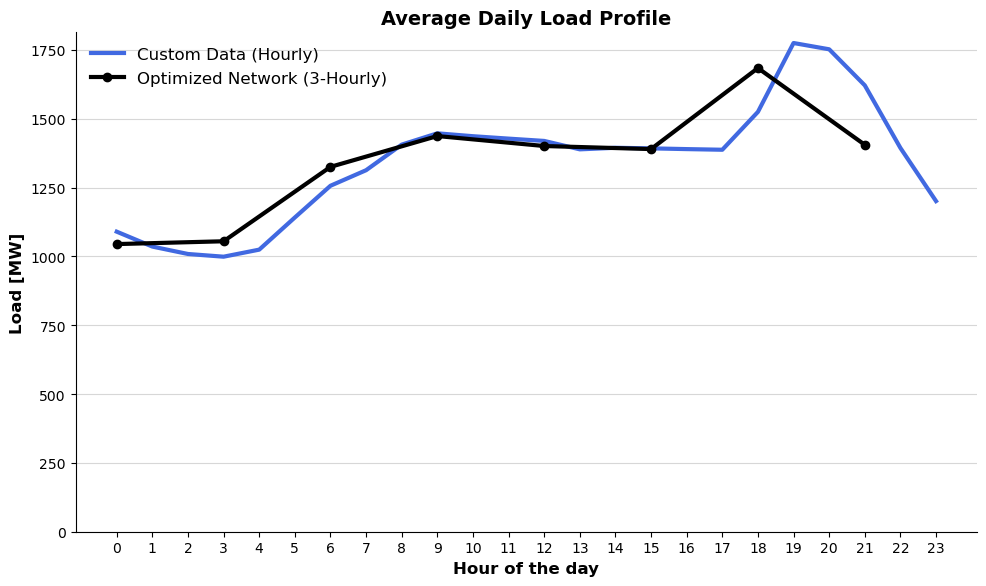

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import register_matplotlib_converters

# 1. Register pandas converters
register_matplotlib_converters()

# 2. Extract the total timeseries for both
total_custom_ts = df_custom.sum(axis=1)
total_network_ts = n_solved.loads_t.p_set.sum(axis=1)

# 3. Force both indices to be proper Datetime objects (timezone naive)
total_custom_ts.index = pd.to_datetime(total_custom_ts.index).tz_localize(None)
total_network_ts.index = pd.to_datetime(total_network_ts.index).tz_localize(None)

# 4. Group by the hour of the day (0 to 23) and calculate the mean
custom_daily_profile = total_custom_ts.groupby(total_custom_ts.index.hour).mean()
network_daily_profile = total_network_ts.groupby(total_network_ts.index.hour).mean()

# 5. Set up the figure
plt.figure(figsize=(10, 6))

# 6. Plot Custom Data (Hourly -> 24 points)
plt.plot(
    custom_daily_profile.index, 
    custom_daily_profile.values, 
    color='royalblue', 
    linewidth=3, 
    label='Custom Data (Hourly)'
)

# 7. Plot Optimized Network Data (3-Hourly -> 8 points)
# Adding markers ('o') helps visualize where the 3-hour chunks actually sit
plt.plot(
    network_daily_profile.index, 
    network_daily_profile.values, 
    color='black', 
    linewidth=3, 
    marker='o',
    label='Optimized Network (3-Hourly)'
)

# 8. Formatting to match the provided Excel-style image
plt.title("Average Daily Load Profile", fontsize=14, fontweight='bold')
plt.xlabel("Hour of the day", fontsize=12, fontweight='bold')
plt.ylabel("Load [MW]", fontsize=12, fontweight='bold')

# Ensure x-axis shows all 24 hours ticks (0 to 23)
plt.xticks(range(0, 24))

# Set y-axis lower limit to 0 to match the scale in your image
plt.ylim(bottom=0)

# Add horizontal grid lines similar to the image
plt.grid(axis='y', linestyle='-', alpha=0.5)

# Add legend and render
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

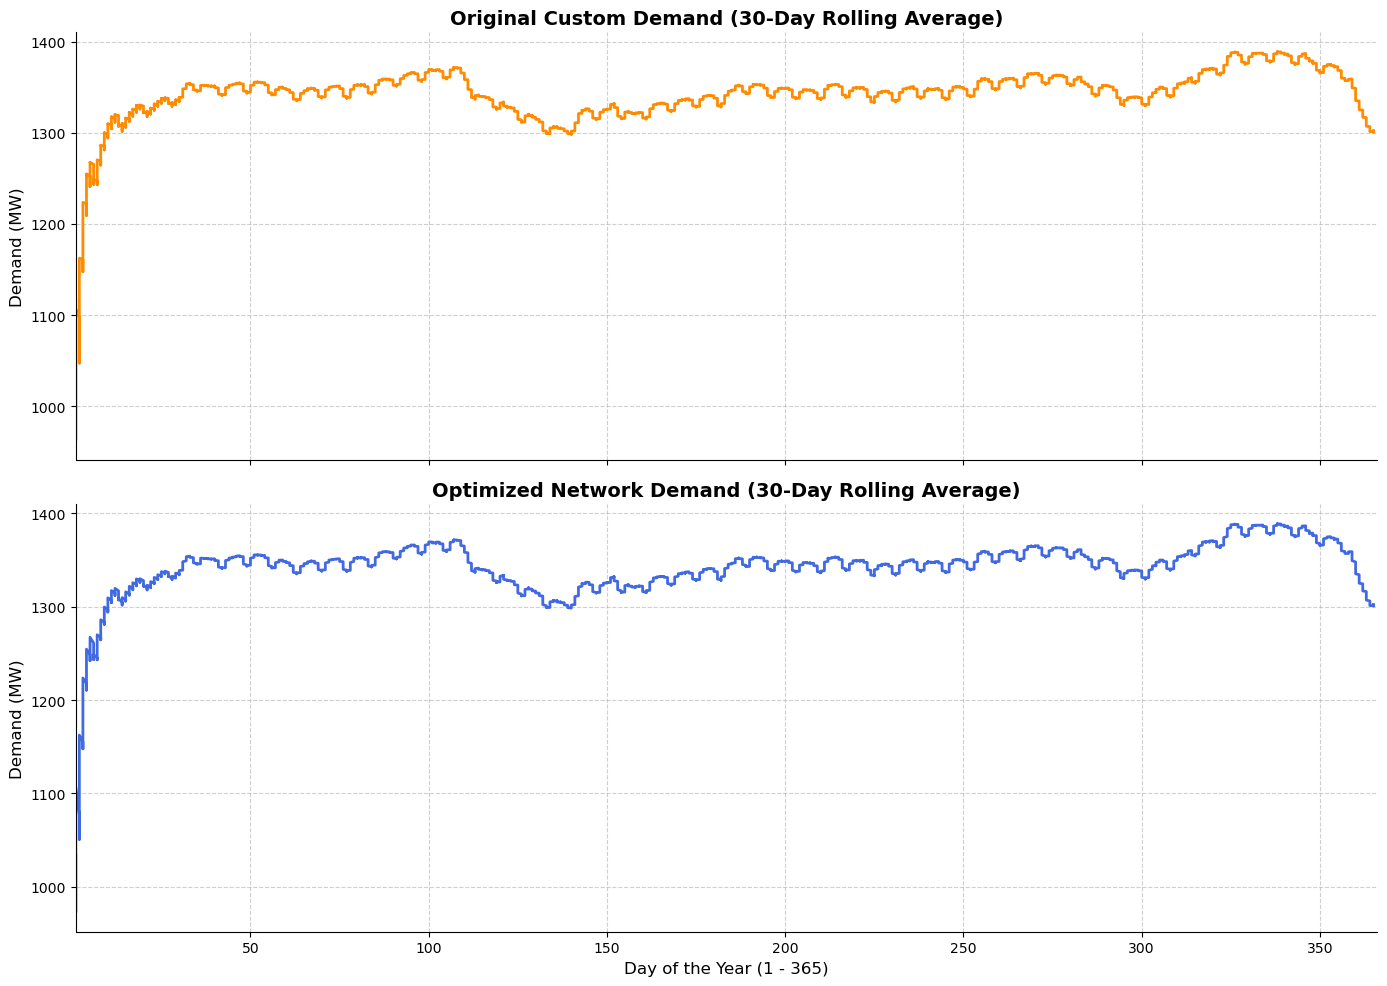

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import register_matplotlib_converters

# 1. Register pandas converters
register_matplotlib_converters()

# 2. Extract the total timeseries for both
total_custom_ts = df_custom.sum(axis=1)
total_network_ts = n_solved.loads_t.p_set.sum(axis=1)

# 3. Force both indices to be proper Datetime objects (timezone naive)
total_custom_ts.index = pd.to_datetime(total_custom_ts.index).tz_localize(None)
total_network_ts.index = pd.to_datetime(total_network_ts.index).tz_localize(None)

# 4. Calculate the 10-day rolling average
custom_rolling_10d = total_custom_ts.rolling(window='30D').mean()
network_rolling_10d = total_network_ts.rolling(window='30D').mean()

# 5. Extract the "Day of the Year" (1 to 365/366) from the index
custom_doy = custom_rolling_10d.index.dayofyear
network_doy = network_rolling_10d.index.dayofyear

# 6. Set up the figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# 7. Plot Original Custom Demand vs. Day of the Year
ax1.plot(custom_doy, custom_rolling_10d.values, color='darkorange', linewidth=2)
ax1.set_title("Original Custom Demand (30-Day Rolling Average)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Demand (MW)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# 8. Plot Optimized Network Demand vs. Day of the Year
ax2.plot(network_doy, network_rolling_10d.values, color='royalblue', linewidth=2)
ax2.set_title("Optimized Network Demand (30-Day Rolling Average)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Day of the Year (1 - 365)", fontsize=12)
ax2.set_ylabel("Demand (MW)", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

# 9. Set x-axis limits to enforce the 1-365 day view
plt.xlim(1, 366)

# 10. Final layout adjustments and rendering
plt.tight_layout()
plt.show()

3. EXISTING vs NEW CAPACITY COMPARISON

Carrier              Existing (MW)      New (MW)   Total (MW)    % New
---------------------------------------------------------------------------
  biomass *                   13.4           0.0         13.4     0.0%
  geothermal *               960.5           0.0        960.5     0.0%
  import_ethiopia            400.0           0.0        400.0     0.0%
  import_uganda               50.0           0.0         50.0     0.0%
  oil                        717.3           0.0        717.3     0.0%
  onwind *                   435.5           0.0        435.5     0.0%
  ror *                      407.8           0.0        407.8     0.0%
  solar *                    256.5           0.0        256.5     0.0%


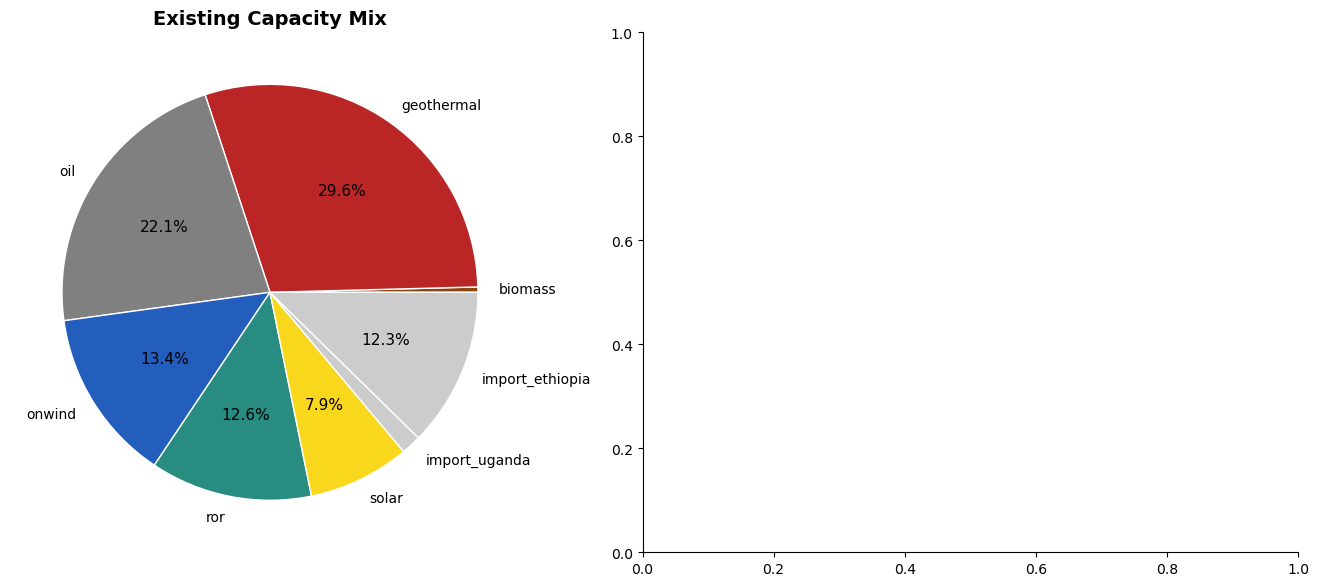

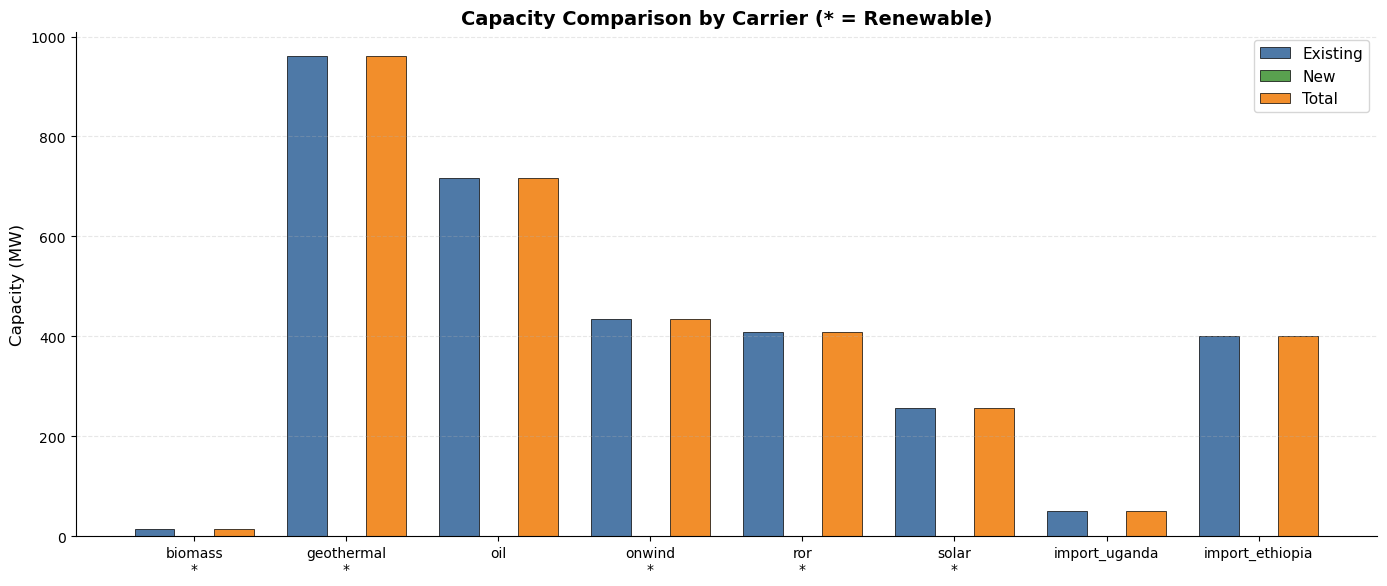

In [8]:
print("=" * 80)
print("3. EXISTING vs NEW CAPACITY COMPARISON")
print("=" * 80)

def classify(row):
    if not row["p_nom_extendable"]:
        return row["p_nom"], 0.0, row["p_nom"] 
    else:
        existing = row["p_nom_min"]            
        new = max(0.0, row["p_nom_opt"] - row["p_nom_min"])
        return existing, new, row["p_nom_opt"]

gen[["existing_MW", "new_MW", "total_MW"]] = gen.apply(classify, axis=1, result_type="expand")

summary_carriers = [c for c in gen["carrier"].unique() if gen.loc[gen["carrier"] == c, "total_MW"].sum() > 0]
print(f"\n{'Carrier':<18} {'Existing (MW)':>15} {'New (MW)':>13} {'Total (MW)':>12} {'% New':>8}")
print("-" * 75)
for c in sorted(summary_carriers):
    row = gen[gen["carrier"] == c]
    ex, nw, tot = row["existing_MW"].sum(), row["new_MW"].sum(), row["total_MW"].sum()
    pct = (nw / tot * 100) if tot > 0 else 0
    flag = " *" if c in RENEWABLE_CARRIERS else ""
    print(f"  {c+flag:<16} {ex:>15.1f} {nw:>13.1f} {tot:>12.1f} {pct:>7.1f}%")

# ── Publishable Pie Charts ──
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))

ex_by_carrier = {c: gen.loc[gen["carrier"] == c, "existing_MW"].sum() for c in summary_carriers}
ex_by_carrier = {k: v for k, v in ex_by_carrier.items() if v > 0}
axes1[0].pie(ex_by_carrier.values(), labels=ex_by_carrier.keys(), 
            colors=[CARRIER_COLORS.get(c, '#ccc') for c in ex_by_carrier], 
            autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
            wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes1[0].set_title("Existing Capacity Mix", fontweight='bold')

nw_by_carrier = {c: gen.loc[gen["carrier"] == c, "new_MW"].sum() for c in summary_carriers}
nw_by_carrier = {k: v for k, v in nw_by_carrier.items() if v > 0}
if nw_by_carrier:
    axes1[1].pie(nw_by_carrier.values(), labels=nw_by_carrier.keys(), 
                colors=[CARRIER_COLORS.get(c, '#ccc') for c in nw_by_carrier], 
                autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
                wedgeprops={'edgecolor': 'white', 'linewidth': 1})
    axes1[1].set_title("New Capacity Mix (Added by Optimiser)", fontweight='bold')

fig1.savefig(f"{OUT_DIR}/02_pie_existing_vs_new.png")
fig1.savefig(f"{OUT_DIR}/02_pie_existing_vs_new.pdf")
plt.show()

# ── Publishable Grouped Bar Chart ──
x = np.arange(len(summary_carriers))
w = 0.26
fig2, ax2 = plt.subplots(figsize=(14, 6))

ex_vals = [gen.loc[gen["carrier"] == c, "existing_MW"].sum() for c in summary_carriers]
nw_vals = [gen.loc[gen["carrier"] == c, "new_MW"].sum() for c in summary_carriers]
tot_vals = [gen.loc[gen["carrier"] == c, "total_MW"].sum() for c in summary_carriers]

ax2.bar(x - w, ex_vals, width=w, label="Existing", color="#4e79a7", edgecolor='black', linewidth=0.5)
ax2.bar(x, nw_vals, width=w, label="New", color="#59a14f", edgecolor='black', linewidth=0.5)
ax2.bar(x + w, tot_vals, width=w, label="Total", color="#f28e2b", edgecolor='black', linewidth=0.5)

ax2.set_xticks(x)
ax2.set_xticklabels([f"{c}\n*" if c in RENEWABLE_CARRIERS else c for c in summary_carriers], rotation=0)
ax2.set_ylabel("Capacity (MW)")
ax2.set_title("Capacity Comparison by Carrier (* = Renewable)", fontweight='bold')
ax2.legend()
ax2.grid(axis="y", alpha=0.3, linestyle='--')

fig2.savefig(f"{OUT_DIR}/03_bar_existing_vs_new.png")
fig2.savefig(f"{OUT_DIR}/03_bar_existing_vs_new.pdf")
plt.show()

4. SPATIAL DISTRIBUTION OF INSTALLED CAPACITY


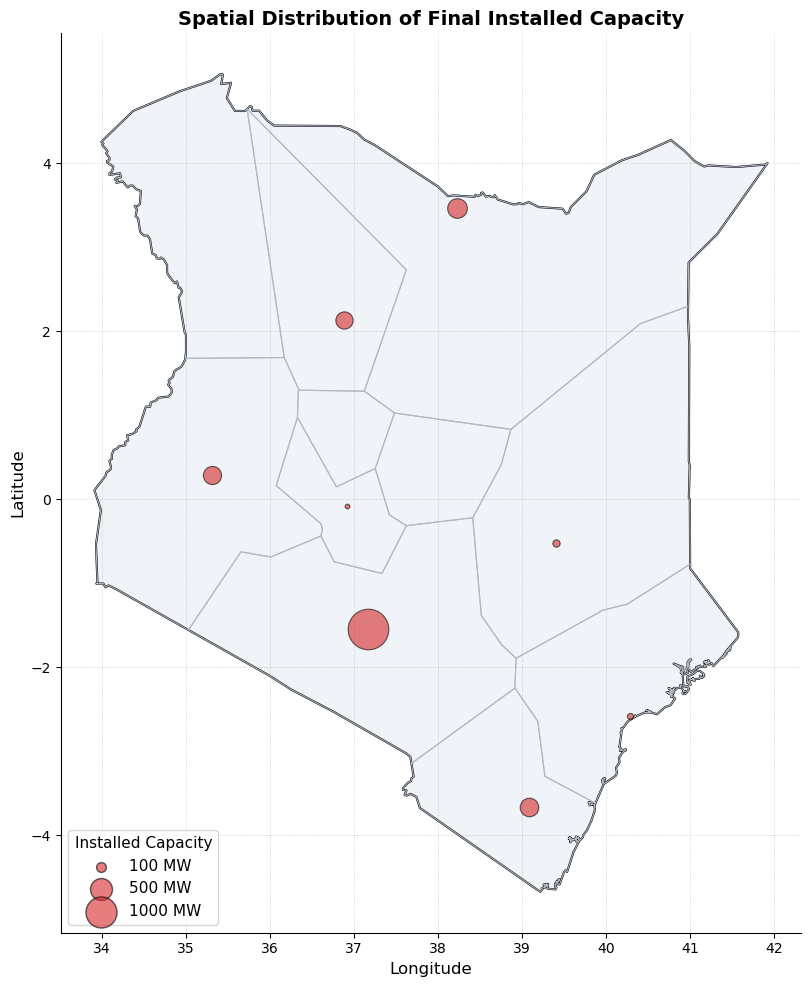


Interactive Map Preview:


In [9]:
print("=" * 80)
print("4. SPATIAL DISTRIBUTION OF INSTALLED CAPACITY")
print("=" * 80)

buses_in_kenya = n_solved.buses[n_solved.buses.index.str.contains('KE', case=False, na=False)].copy()
bus_capacities = gen.groupby('bus')['Capacity_MW'].sum()

# ── A. Publishable Static Capacity Map ──
fig, ax = plt.subplots(figsize=(10, 10))

if country_outline is not None:
    country_outline.plot(ax=ax, facecolor='#f0f4f8', edgecolor='black', linewidth=1.5, zorder=1)
    regions_gdf.plot(ax=ax, facecolor='none', edgecolor='#b0b8c4', linewidth=0.8, linestyle='-', zorder=2)

# Plot capacities as sized bubbles
for idx, row in buses_in_kenya.iterrows():
    if idx in bus_capacities and bus_capacities[idx] > 0:
        cap = bus_capacities[idx]
        ax.scatter(row['x'], row['y'], s=cap * 0.5, color='#d62728', alpha=0.6, 
                   edgecolor='black', linewidth=0.8, zorder=4)

# Create a custom size legend for the bubbles
legend_sizes = [100, 500, 1000]
legend_handles = [plt.scatter([], [], s=size * 0.5, color='#d62728', alpha=0.6, edgecolor='black') for size in legend_sizes]
ax.legend(legend_handles, [f"{size} MW" for size in legend_sizes], 
          title="Installed Capacity", loc='lower left', frameon=True)

ax.set_title("Spatial Distribution of Final Installed Capacity", fontweight='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect('equal')
ax.grid(color='grey', linestyle=':', linewidth=0.5, alpha=0.5)

fig.savefig(f"{OUT_DIR}/04_static_capacity_map.png")
fig.savefig(f"{OUT_DIR}/04_static_capacity_map.pdf")
plt.show()

# ── B. Interactive Folium Map (For Browser Exploration) ──
if len(buses_in_kenya) > 0:
    m = folium.Map(location=[buses_in_kenya['y'].mean(), buses_in_kenya['x'].mean()], zoom_start=6, tiles='CartoDB positron')
    max_capacity = bus_capacities.max()
    
    for idx, row in buses_in_kenya.iterrows():
        bus_gens = gen[gen['bus'] == idx]
        bus_cap = bus_gens['Capacity_MW'].sum()
        
        if bus_cap > 0:
            norm_cap = bus_cap / max_capacity
            color = '#800026' if norm_cap > 0.75 else '#bd0026' if norm_cap > 0.5 else '#fd8d3c' if norm_cap > 0.25 else '#fed976'
            
            mix = bus_gens.groupby('carrier')['Capacity_MW'].sum().sort_values(ascending=False)
            html = f"<div style='font-family: Arial;'><h4>{idx}</h4><b>Total: {bus_cap:.1f} MW</b><hr><table style='width: 100%;'>"
            for c, cp in mix.items():
                html += f"<tr><td>{c}</td><td style='text-align: right;'><b>{cp:.1f} MW</b></td></tr>"
            html += "</table></div>"
            
            folium.CircleMarker(
                location=[row['y'], row['x']], radius=np.sqrt(bus_cap/15), color=color,
                fill=True, fillOpacity=0.7, weight=1
            ).add_to(m)
            
            folium.Marker(
                location=[row['y'], row['x']],
                icon=folium.DivIcon(html=f"<div style='font-size:10px; font-weight:bold; color:black; width:60px; margin-left:-30px;'>{idx}</div>"),
                popup=folium.Popup(html, max_width=250)
            ).add_to(m)

    m.save(f'{OUT_DIR}/05_interactive_cluster_map.html')
    print("\nInteractive Map Preview:")
    display(m)

In [10]:
print("=" * 80)
print("5. TRANSMISSION & POWER FLOW UTILIZATION")
print("=" * 80)

lines = n_solved.lines.copy()
if hasattr(n_solved.lines_t, 'p0') and len(n_solved.lines_t.p0) > 0:
    avg_flows = n_solved.lines_t.p0.mean()
    sorted_flows = avg_flows.abs().sort_values(ascending=False)
    
    print(f"{'From':<10} {'To':<10} {'Avg Flow (MW)':>15} {'Capacity (MW)':>15} {'Util. %':>10}")
    print("-" * 65)
    
    total_avg = total_cap = 0
    for l_idx in sorted_flows.index:
        af = abs(avg_flows[l_idx])
        cap = lines.loc[l_idx, 's_nom_opt']
        util = (af / cap * 100) if cap > 0 else 0
        
        if af > 0.01:
            print(f"{lines.loc[l_idx, 'bus0']:<10} {lines.loc[l_idx, 'bus1']:<10} {af:>15.2f} {cap:>15.2f} {util:>9.1f}%")
            total_avg += af
            total_cap += cap
            
    print("-" * 65)
    print(f"Network Utilization: {(total_avg / total_cap * 100) if total_cap > 0 else 0:.2f}%")
else:
    print("No time-series line flow data available.")

5. TRANSMISSION & POWER FLOW UTILIZATION
From       To           Avg Flow (MW)   Capacity (MW)    Util. %
-----------------------------------------------------------------
KE0 0      KE0 6               319.57         3869.89       8.3%
KE0 0      KE0 1               142.46         4213.98       3.4%
KE0 4      KE0 7                70.33          152.92      46.0%
KE0 1      KE0 3                47.54          491.56       9.7%
KE0 4      KE0 8                40.47          294.94      13.7%
KE0 0      KE0 8                19.96          147.47      13.5%
KE0 0      KE0 2                16.18          147.47      11.0%
KE0 2      KE0 3                10.70           30.74      34.8%
KE0 5      KE0 6                 9.78          983.12       1.0%
KE0 0      KE0 4                 8.07          147.47       5.5%
KE0 0      KE0 7                 6.39         3574.95       0.2%
KE0 5      KE0 8                 0.45           12.88       3.5%
------------------------------------------------

6. TIME-SERIES DISPATCH (14-DAY)


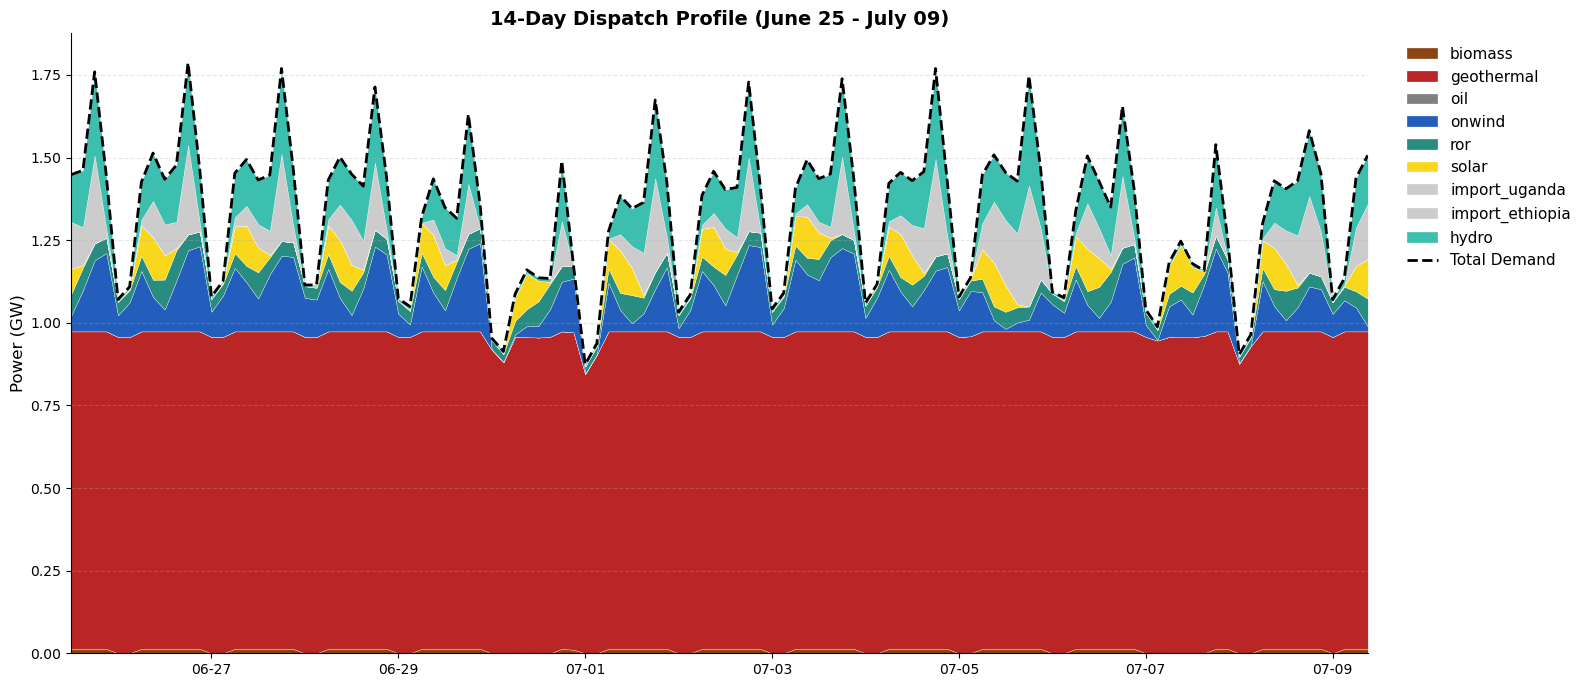

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("=" * 80)
print("6. TIME-SERIES DISPATCH (14-DAY)")
print("=" * 80)

# Initialize DataFrames for the stack plots
dispatch_pos = pd.DataFrame(index=n_solved.snapshots) # Generation & Discharging
dispatch_neg = pd.DataFrame(index=n_solved.snapshots) # Charging (plotted below 0)

# ── 1. PROCESS GENERATORS ──
if hasattr(n_solved, 'generators_t') and not n_solved.generators_t.p.empty:
    for carrier in n_solved.generators.carrier.unique():
        cols = n_solved.generators[n_solved.generators.carrier == carrier].index
        dispatch_pos[carrier] = n_solved.generators_t.p[cols].sum(axis=1)

# ── 2. PROCESS STORAGE UNITS (e.g., Hydro Reservoirs) ──
if hasattr(n_solved, 'storage_units_t') and not n_solved.storage_units_t.p.empty:
    for carrier in n_solved.storage_units.carrier.unique():
        cols = n_solved.storage_units[n_solved.storage_units.carrier == carrier].index
        su_p = n_solved.storage_units_t.p[cols].sum(axis=1)
        
        # Positive values = Discharging to the grid
        discharge = su_p.clip(lower=0)
        if carrier in dispatch_pos.columns:
            dispatch_pos[carrier] += discharge
        else:
            dispatch_pos[carrier] = discharge
            
        # Negative values = Charging from the grid
        dispatch_neg[f"{carrier} (Charge)"] = su_p.clip(upper=0)

# ── 3. PROCESS LINKS FOR BATTERIES (Store + Link model) ──
if hasattr(n_solved, 'links_t') and not n_solved.links_t.p0.empty:
    for c in n_solved.links.carrier.unique():
        cols = n_solved.links[n_solved.links.carrier == c].index
        
        # Dischargers inject power to the AC grid (PyPSA link p1 is negative for injection)
        if 'discharger' in str(c).lower():
            base_c = c.replace(' discharger', '').replace(' Discharger', '')
            discharge = -n_solved.links_t.p1[cols].sum(axis=1) 
            
            if base_c in dispatch_pos.columns:
                dispatch_pos[base_c] += discharge
            else:
                dispatch_pos[base_c] = discharge
                
        # Chargers draw power from the AC grid (PyPSA link p0 is positive for draw)
        elif 'charger' in str(c).lower():
            base_c = c.replace(' charger', '').replace(' Charger', '')
            # Make the draw negative so it plots below the zero axis
            dispatch_neg[f"{base_c} (Charge)"] = -n_solved.links_t.p0[cols].sum(axis=1)

# Convert MW to GW
dispatch_pos = dispatch_pos / 1e3
dispatch_neg = dispatch_neg / 1e3

# ── 4. EXACT NETWORK DEMAND ──
# Pull the exact demand the solver had to meet, accounting for 3h resampling
demand_actual = None
if hasattr(n_solved, 'loads_t') and not n_solved.loads_t.p_set.empty:
    demand_actual = n_solved.loads_t.p_set.sum(axis=1) / 1e3

# Clean up any all-zero columns to keep the legend tidy
dispatch_pos = dispatch_pos.loc[:, (dispatch_pos != 0).any(axis=0)]
dispatch_neg = dispatch_neg.loc[:, (dispatch_neg != 0).any(axis=0)]

# ── 5. PUBLISHABLE 14-DAY STACKED AREA ──
# Calculate step size dynamically so it works for 1h, 3h, or any temporal resolution
hours_per_step = (n_solved.snapshots[1] - n_solved.snapshots[0]).total_seconds() / 3600
window_steps = int((14 * 24) / hours_per_step)

start_idx = max(0, len(dispatch_pos) // 2 - window_steps // 2)
end_idx = min(len(dispatch_pos), start_idx + window_steps)

start_date = dispatch_pos.index[start_idx]
end_date = dispatch_pos.index[end_idx - 1]

df_14d_pos = dispatch_pos.iloc[start_idx:end_idx]
df_14d_neg = dispatch_neg.iloc[start_idx:end_idx]

active_pos_carriers = df_14d_pos.columns.tolist()
active_neg_carriers = df_14d_neg.columns.tolist()

fig2, ax2 = plt.subplots(figsize=(16, 7))

# Plot Positive Stack (Generation & Discharge)
if active_pos_carriers:
    ax2.stackplot(df_14d_pos.index, [df_14d_pos[c] for c in active_pos_carriers], 
                  labels=active_pos_carriers, 
                  colors=[CARRIER_COLORS.get(c, '#ccc') for c in active_pos_carriers],
                  edgecolor='white', linewidth=0.2)
                  
# Plot Negative Stack (Charging)
if active_neg_carriers:
    ax2.stackplot(df_14d_neg.index, [df_14d_neg[c] for c in active_neg_carriers], 
                  labels=active_neg_carriers, 
                  colors=[CARRIER_COLORS.get(c.split(' ')[0], '#ccc') for c in active_neg_carriers],
                  edgecolor='white', linewidth=0.2, alpha=0.6)
    
# Plot Actual Solver Demand
if demand_actual is not None:
    dem_14d = demand_actual.iloc[start_idx:end_idx]
    ax2.plot(dem_14d.index, dem_14d.values, color='black', ls='--', lw=2, label='Total Demand')
    
ax2.set_ylabel('Power (GW)')
ax2.set_title(f'14-Day Dispatch Profile ({start_date.strftime("%B %d")} - {end_date.strftime("%B %d")})', fontweight='bold')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=0)
plt.margins(x=0)

fig2.savefig(f"{OUT_DIR}/07_14_day_dispatch_corrected.png", bbox_inches='tight')
plt.show()

8. AVERAGE DAILY DISPATCH & DEMAND PROFILE


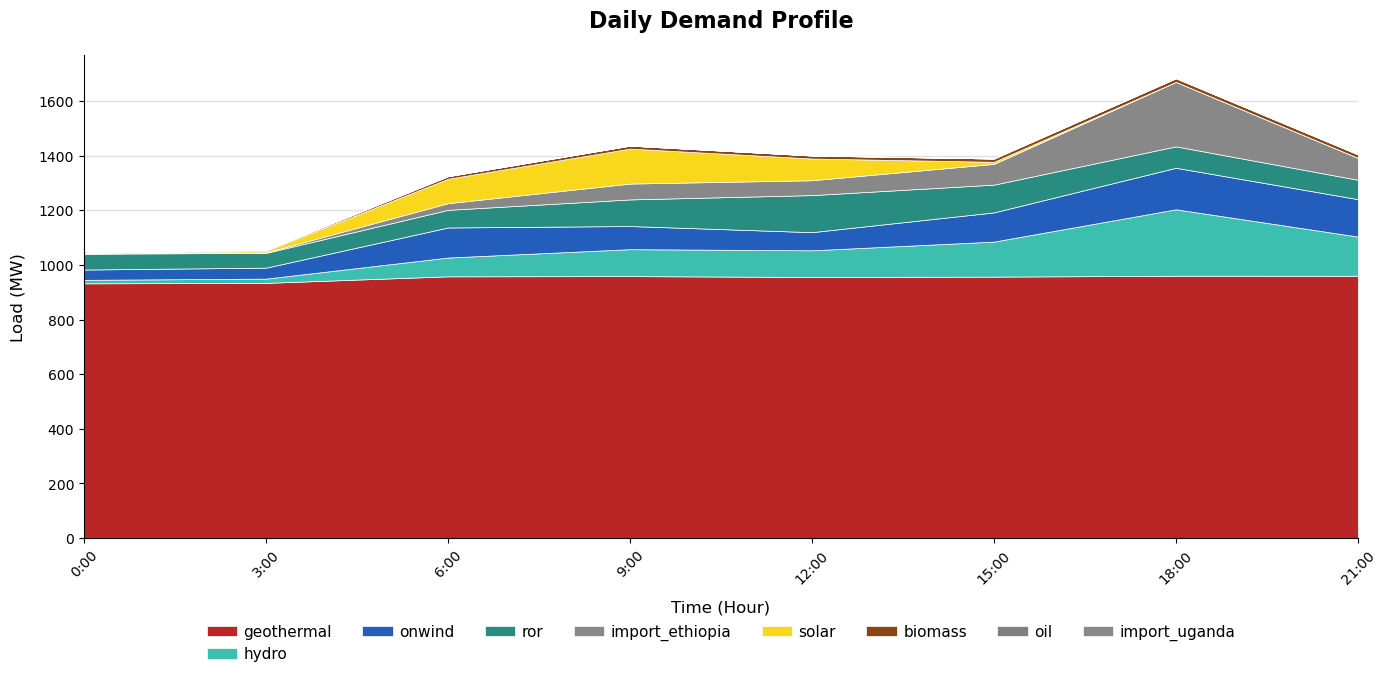

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("8. AVERAGE DAILY DISPATCH & DEMAND PROFILE")
print("=" * 80)

# 1. Initialize DataFrame for all positive dispatch (MW)
dispatch_all = pd.DataFrame(index=n_solved.snapshots)

# ── Extract Generators ──
if hasattr(n_solved, 'generators_t') and not n_solved.generators_t.p.empty:
    for c in n_solved.generators.carrier.unique():
        cols = n_solved.generators[n_solved.generators.carrier == c].index
        dispatch_all[c] = n_solved.generators_t.p[cols].sum(axis=1)

# ── Extract Storage Units (Discharging) ──
if hasattr(n_solved, 'storage_units_t') and not n_solved.storage_units_t.p.empty:
    for c in n_solved.storage_units.carrier.unique():
        cols = n_solved.storage_units[n_solved.storage_units.carrier == c].index
        # Only take positive values (discharging to the grid)
        discharge = n_solved.storage_units_t.p[cols].sum(axis=1).clip(lower=0)
        
        if c in dispatch_all.columns:
            dispatch_all[c] += discharge
        else:
            dispatch_all[c] = discharge

# ── Extract Links (Batteries & Imports) ──
if hasattr(n_solved, 'links_t') and not n_solved.links_t.p0.empty:
    for c in n_solved.links.carrier.unique():
        # Capture battery dischargers or cross-border imports
        if 'discharger' in str(c).lower() or 'import' in str(c).lower():
            cols = n_solved.links[n_solved.links.carrier == c].index
            # Link p1 is negative when injecting power into the AC grid, so we flip the sign
            discharge = -n_solved.links_t.p1[cols].sum(axis=1)
            
            base_c = str(c).replace(' discharger', '').replace(' Discharger', '')
            if base_c in dispatch_all.columns:
                dispatch_all[base_c] += discharge
            else:
                dispatch_all[base_c] = discharge

# Filter out carriers that produced 0 MW across the entire timeframe
dispatch_all = dispatch_all.loc[:, (dispatch_all != 0).any(axis=0)]

# 2. Calculate the Average Daily Profile
# Group by the hour of the day and take the mean
# Note: If your model is 3-hourly, this will generate 8 data points per day (0, 3, 6, 9...)
hourly_avg = dispatch_all.groupby(dispatch_all.index.hour).mean()

# Sort columns so the largest total energy contributors (like Geothermal/Hydro) form the base of the stack
carrier_order = hourly_avg.sum().sort_values(ascending=False).index.tolist()

# 3. Plotting (Styled to match image_5bfa42.png)
fig, ax = plt.subplots(figsize=(14, 7))

# Create the stacked area chart
ax.stackplot(hourly_avg.index, 
             [hourly_avg[c] for c in carrier_order],
             labels=carrier_order,
             colors=[CARRIER_COLORS.get(c, '#888888') for c in carrier_order],
             linewidth=0.5, edgecolor='white')

# 4. Formatting and Aesthetics
ax.set_title("Daily Demand Profile", fontweight='bold', fontsize=16, pad=20)
ax.set_ylabel("Load (MW)", fontsize=12, labelpad=10)
ax.set_xlabel("Time (Hour)", fontsize=12, labelpad=10)

# Format the x-axis to look like time (e.g., 0:00, 3:00, 6:00)
ax.set_xticks(hourly_avg.index)
ax.set_xticklabels([f"{int(h)}:00" for h in hourly_avg.index], rotation=45)

# Ensure axes start cleanly at 0
ax.set_xlim(hourly_avg.index.min(), hourly_avg.index.max())
ax.set_ylim(bottom=0)

# Add horizontal gridlines similar to the reference image
ax.yaxis.grid(True, color='#e0e0e0', linestyle='-', linewidth=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True) # Put grid behind the plots

# Remove the top and right bounding box borders for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Place the legend at the bottom horizontally
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=min(len(carrier_order), 8), frameon=False, 
          fontsize=11, handletextpad=0.4)

plt.tight_layout()
fig.savefig(f"{OUT_DIR}/08_average_daily_profile.png", dpi=300, bbox_inches='tight')
fig.savefig(f"{OUT_DIR}/08_average_daily_profile.pdf", bbox_inches='tight')
plt.show()